# Challenge 20 - Adaptive Step Size

Inference: This code will likely solve stiff ODEs by combining both Backward Euler for timestepping with Newton Raphson to deal with the implicit solve at each step, using step-doubling to iteratively control accuracy.

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [74]:
# Newton-Raphson for single step with Backward Euler
def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=50):
    y_next = y # Initial guess
    for _ in range(max_iter):
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)
        
        if abs(g_prime_val) < tol: # Avoid division by zero
            break
        
        y_new = y_next - g_val / g_prime_val
        if abs(y_new - y_next) < tol:
            return y_new # Converged
        y_next = y_new
        
    return y_next


# Adaptive Backward Euler
def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=50):
    t_values = [t0]
    y_values = [y0]
    h = h_init
    t = t0
    y = y0

    while t < tf:
        if t + h > tf: # Adjust step size to not overshoot
            h = tf - t

        # Single step with h
        y_full = backward_euler_step(f, y, t, h, tol, max_iter)

        # Two half-steps with h/2
        h_half = h / 2
        y_half_1 = backward_euler_step(f, y, t, h_half, tol, max_iter)
        y_half_2 = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter)

        # Error estimation
        error = abs(y_full - y_half_2)
        
        # Adjust step size
        if error > tol:
            h /= 2 # Decrease step size
            continue # Retry the step with smaller h
        elif error < tol / 2:
            h *= 2 # Increase step size for efficiency
            
        # Accept the step
        t += h
        y = y_half_2
        t_values.append(t)
        y_values.append(y)

    return np.array(t_values), np.array(y_values)

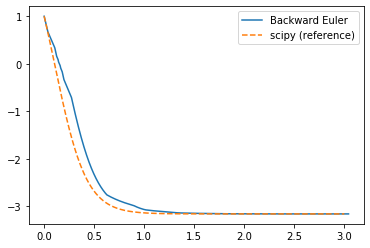

In [75]:
def f(t,y):
    return y**2 - 10

def fprime(y):
    return 2*y  

t0=0.0
y0=1.0 # y0 < sqrt(10), so solution will decay toward -sqrt(10)

t_vals, y_vals = backward_euler_adaptive(f, y0, t0, tf = 3, h_init = 0.1)
sol = solve_ivp(f, [t0, 3], [y0], max_step=0.001)

plt.plot(t_vals, y_vals, label="Backward Euler")
plt.plot(sol.t, sol.y[0], '--', label="scipy (reference)")
plt.legend()
plt.show()

Conclusion: The adaptive Backward Euler solver does approximate the solution to dy/dt = y^2 - 10 with y0=1 pretty well, which also closely matching the scipy solution. The solution decays toward the stable equilibrium at -sqrt(10) = -3.16, confirming  that starting below sqrt(10) the system is attracted downward. The adaptive step size control ensures the it keeps accuracy efficiently, where it will take larger steps where the solution changes slowly and smaller steps where it changes quickly.